#Fase 4 y 5 — Deep Learning + Evaluation (CRISP-DM)
#Sistema Inteligente de Recomendación de Películas — MovieLens 25M

Notebook `04_DeepLearning_Embeddings.ipynb` — **CRISP-DM Fase 4 (Modeling)** + **CRISP-DM Fase 5 (Evaluation)**.

Continuamos desde la Fase 4 clásica (`03_ML_Baseline_AutoML.ipynb`) que dejó establecido el límite del Machine Learning tabular:
* **SVD (Matrix Factorization)** como el campeón clásico con un RMSE de **0.8140**.
* Clústeres de usuarios y películas extraídos y persistidos.

Este notebook cubre la transición hacia arquitecturas no lineales:
* **Modeling (Fase 4):** Diseño, construcción y entrenamiento de una red Neural Collaborative Filtering (NCF) con PyTorch.
* **Evaluation (Fase 5):** Análisis de curvas de aprendizaje, diagnóstico de sobreajuste y comparativa directa contra el modelo clásico.

### Entregables de este notebook (especificaciones del proyecto)

| # | Entregable | Implementación en este notebook |
| :--- | :--- | :--- |
| 1 | **Diseño e implementación del modelo** profundo. | Sección 3 — **Arquitectura NCF** (Neural Collaborative Filtering) de Dos Torres. |
| 2 | **Embeddings o representación latente** explícita. | Sección 3 — Capas `nn.Embedding` de 64 dimensiones para usuarios y películas. |
| 3 | **Entrenamiento y evaluación**. | Sección 4 — Bucle de 10 épocas con registro estricto de MSELoss y RMSE. |
| 4 | **Curvas de entrenamiento** y explicación de sobreajuste. | Sección 5 — Visualización de curvas de aprendizaje y diagnóstico de **Overfitting**. |
| 5 | **Comparación con baseline clásico**. | Sección 6 — Gráfico comparativo y tabla de RMSE (NCF vs SVD). |

### Decisiones metodológicas clave

1. **Biblioteca:** `PyTorch` — estándar en la industria para arquitecturas profundas, permite control total sobre los grafos y los embeddings latentes.
2. **Dataset:** Muestra temporal del **5%** — clonada directamente desde GitHub para garantizar la ejecución en hardware local y evidenciar empíricamente la dependencia de datos del Deep Learning (Data Starvation).
3. **Función de pérdida:** `MSELoss` — al predecir un rating continuo (0.5 a 5.0), el error cuadrático medio es la métrica matemáticamente correcta para penalizar errores severos.
4. **Regularización:** `Dropout (0.2)` y `Weight Decay (L2)` — incorporados en la arquitectura para mitigar la rápida memorización de la red neuronal.

In [1]:
# ==========================================
# 1. IMPORTACIONES Y ENTORNO
# ==========================================
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Configuración visual
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

# Reproducibilidad estricta
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo de entrenamiento configurado: {device}")


Dispositivo de entrenamiento configurado: cpu


### 1. Preparación de Datos (PyTorch DataLoaders)
Cargaremos el subconjunto de datos procesado en la Fase 2 (formato Parquet). En PyTorch, necesitamos mapear los IDs de usuarios y películas a índices continuos que comiencen desde cero, para que puedan ser leídos correctamente por las capas `nn.Embedding`.

In [2]:

# ==========================================
# 2. CARGA DE DATOS (LOCAL — ajuste automático de ruta)
# ==========================================
from pathlib import Path
import os

# Detectar raíz del repositorio (busca requirements.txt hacia arriba)
def _find_repo_root():
    current = Path(os.getcwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'requirements.txt').exists() and (candidate / 'notebooks').exists():
            return candidate
    return current  # fallback: directorio actual

ROOT = _find_repo_root()
if str(ROOT) != os.getcwd():
    os.chdir(str(ROOT))
    print(f"Directorio ajustado a raíz del repo: {ROOT}")
else:
    print(f"Directorio de trabajo correcto: {ROOT}")

ruta_parquet = 'data/intermediate/ratings_sample_5pct.parquet'

try:
    ratings = pd.read_parquet(ruta_parquet)
    print(f"¡Datos cargados exitosamente! Shape: {ratings.shape}")
except FileNotFoundError:
    print(f"ERROR: No se encontró '{ruta_parquet}'")
    raise

# 2.1 Mapeo de IDs a índices continuos para PyTorch (obligatorio para nn.Embedding)
user_ids  = ratings['userId'].unique()
movie_ids = ratings['movieId'].unique()

user2idx  = {o: i for i, o in enumerate(user_ids)}
movie2idx = {o: i for i, o in enumerate(movie_ids)}

ratings['user_idx']  = ratings['userId'].map(user2idx)
ratings['movie_idx'] = ratings['movieId'].map(movie2idx)

num_users  = len(user_ids)
num_movies = len(movie_ids)
print(f"Usuarios únicos: {num_users} | Películas únicas: {num_movies}")


Directorio ajustado a raíz del repo: C:\Users\alvar\Documents\GitHub\OmniRec-Movies
¡Datos cargados exitosamente! Shape: (1152574, 4)


Usuarios únicos: 8126 | Películas únicas: 5915


En esta primera etapa, el entorno de trabajo se conectó exitosamente al repositorio oficial en GitHub, garantizando la trazabilidad exigida por la fase de MLOps. Se descargó la muestra de datos, confirmando la lectura de más de 1.15 millones de interacciones correspondientes a 8,126 usuarios y 5,915 películas únicas. Un paso crítico aquí fue el mapeo de los IDs originales (crudos) a índices categóricos continuos, un requisito obligatorio para que las capas de Embeddings de PyTorch puedan asignar vectores matemáticos correctos a cada entidad sin generar errores de dimensionalidad.

### 2. Preparación de DataLoaders para PyTorch
Para que la red neuronal pueda entrenar de manera eficiente, empaquetamos las interacciones en lotes (*batches*) usando la clase `Dataset` y `DataLoader` nativas de PyTorch. Dividiremos los datos en 80% para entrenamiento y 20% para validación.

In [3]:
# ==========================================
# 3. DATALOADERS (TRAIN / VAL)
# ==========================================

# División 80/20
train_df, val_df = train_test_split(ratings, test_size=0.2, random_state=SEED)

class MovieLensDataset(Dataset):
    def __init__(self, users, items, ratings):
        self.users = torch.tensor(users.values, dtype=torch.long)
        self.items = torch.tensor(items.values, dtype=torch.long)
        self.ratings = torch.tensor(ratings.values, dtype=torch.float32)

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        return self.users[idx], self.items[idx], self.ratings[idx]

train_dataset = MovieLensDataset(train_df['user_idx'], train_df['movie_idx'], train_df['rating'])
val_dataset = MovieLensDataset(val_df['user_idx'], val_df['movie_idx'], val_df['rating'])

# Definimos el tamaño del lote (Batch Size)
BATCH_SIZE = 1024
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("DataLoaders construidos y listos.")

DataLoaders construidos y listos.


Para que el entrenamiento sea computacionalmente viable, los datos procesados fueron empaquetados en objetos DataLoader nativos de PyTorch. El conjunto se dividió en un 80% para entrenamiento y un 20% para validación. Al agrupar las interacciones en lotes (batches) de 1024 registros, optimizamos el uso de la memoria y permitimos que la red neuronal actualice sus pesos de manera iterativa y eficiente mediante el descenso de gradiente estocástico.

### 3. Diseño de la Arquitectura: Neural Collaborative Filtering (NCF)
El modelo NCF utiliza dos "brazos" de Embeddings de 64 dimensiones (uno para usuarios y otro para películas). Estos vectores latentes se concatenan y se pasan a través de un Perceptrón Multicapa (MLP) con funciones de activación ReLU y capas Dropout para regularización.
Al ser un problema de predicción de calificación continua, utilizaremos la función de pérdida **MSELoss**.

In [4]:
# ==========================================
# 4. ARQUITECTURA AVANZADA: NeuMF (GMF + MLP)
# ==========================================

class NeuMF(nn.Module):
    def __init__(self, num_users, num_items, mf_dim=32, mlp_layers=[64, 32, 16], dropout=0.2):
        super(NeuMF, self).__init__()

        # --- RAMA 1: GMF (Generalized Matrix Factorization - El SVD Neuronal) ---
        self.embedding_user_mf = nn.Embedding(num_embeddings=num_users, embedding_dim=mf_dim)
        self.embedding_item_mf = nn.Embedding(num_embeddings=num_items, embedding_dim=mf_dim)

        # --- RAMA 2: MLP (Perceptrón Multicapa) ---
        self.embedding_user_mlp = nn.Embedding(num_embeddings=num_users, embedding_dim=int(mlp_layers[0]/2))
        self.embedding_item_mlp = nn.Embedding(num_embeddings=num_items, embedding_dim=int(mlp_layers[0]/2))

        self.fc_layers = nn.Sequential(
            nn.Linear(mlp_layers[0], mlp_layers[1]),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_layers[1], mlp_layers[2]),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # --- CAPA FINAL (Combina GMF y MLP) ---
        self.output = nn.Linear(in_features=mf_dim + mlp_layers[-1], out_features=1)

    def forward(self, user_indices, item_indices):
        # Embeddings GMF
        user_embedding_mf = self.embedding_user_mf(user_indices)
        item_embedding_mf = self.embedding_item_mf(item_indices)

        # Embeddings MLP
        user_embedding_mlp = self.embedding_user_mlp(user_indices)
        item_embedding_mlp = self.embedding_item_mlp(item_indices)

        # Calcular rama GMF (Multiplicación elemento a elemento, como SVD)
        mf_vector = torch.mul(user_embedding_mf, item_embedding_mf)

        # Calcular rama MLP
        mlp_vector = torch.cat([user_embedding_mlp, item_embedding_mlp], dim=-1)
        mlp_vector = self.fc_layers(mlp_vector)

        # Concatenar ambas ramas
        predict_vector = torch.cat([mf_vector, mlp_vector], dim=-1)

        # Predicción final
        return self.output(predict_vector).squeeze()

# Instanciar el nuevo modelo NeuMF
model = NeuMF(num_users=num_users, num_items=num_movies).to(device)

# Función de pérdida y Optimizador ajustado
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

print("¡Arquitectura NeuMF (GMF + MLP) inicializada correctamente!")

¡Arquitectura NeuMF (GMF + MLP) inicializada correctamente!


En este punto se instanció en memoria la arquitectura de Filtrado Colaborativo Neuronal (NCF). El diseño se compone de dos "torres" iniciales de Embeddings de 64 dimensiones (capturando las características latentes de usuarios y películas), las cuales se concatenan y alimentan un Perceptrón Multicapa (MLP). Se implementaron funciones de activación ReLU y capas Dropout (20%) como mecanismo de regularización. Finalmente, se definió la función de pérdida (MSELoss) adecuada para esta tarea de regresión y el optimizador Adam.

### 4. Bucle de Entrenamiento y Validación
Entrenaremos la red registrando el MSE Loss y el RMSE exacto en cada época. El monitoreo de la curva nos permitirá detectar si existe sobreajuste. Al finalizar, guardaremos los pesos del modelo (`.pt`) para cumplir con los requerimientos de MLOps de la Fase 4.

In [5]:
# ==========================================
# 5. BUCLE DE ENTRENAMIENTO CON EARLY STOPPING
# ==========================================

EPOCHS = 40
PATIENCE = 4  # Cuántas épocas esperar sin mejora antes de detenerse
best_val_rmse = float('inf')
patience_counter = 0

train_losses = []
val_losses = []
val_rmses = []

os.makedirs('models', exist_ok=True)
model_path = 'models/neumf_best_model.pt'

print("Iniciando Entrenamiento (NeuMF con Early Stopping)...\n")
for epoch in range(EPOCHS):
    # --- FASE DE ENTRENAMIENTO ---
    model.train()
    total_train_loss = 0

    for users, items, target_ratings in train_loader:
        users, items, target_ratings = users.to(device), items.to(device), target_ratings.to(device)

        optimizer.zero_grad()
        predictions = model(users, items)
        loss = criterion(predictions, target_ratings)

        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # --- FASE DE VALIDACIÓN ---
    model.eval()
    total_val_loss = 0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for users, items, target_ratings in val_loader:
            users, items, target_ratings = users.to(device), items.to(device), target_ratings.to(device)

            predictions = model(users, items)
            loss = criterion(predictions, target_ratings)
            total_val_loss += loss.item()

            all_preds.extend(predictions.cpu().numpy())
            all_targets.extend(target_ratings.cpu().numpy())

    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    epoch_rmse = np.sqrt(mean_squared_error(all_targets, all_preds))
    val_rmses.append(epoch_rmse)

    print(f"Época {epoch+1:02d}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val RMSE: {epoch_rmse:.4f}")

    # --- EARLY STOPPING CHECK ---
    if epoch_rmse < best_val_rmse:
        best_val_rmse = epoch_rmse
        patience_counter = 0
        torch.save(model.state_dict(), model_path) # Guardar el mejor modelo
        print(f"   -> 🌟 Nuevo mejor RMSE! Modelo guardado.")
    else:
        patience_counter += 1
        print(f"   -> Sin mejora. Paciencia: {patience_counter}/{PATIENCE}")
        if patience_counter >= PATIENCE:
            print(f"\n⏹️ Early Stopping activado en la época {epoch+1}. El modelo dejó de mejorar.")
            break

print(f"\n✅ Entrenamiento finalizado. El mejor modelo se guardó en '{model_path}' con un RMSE de {best_val_rmse:.4f}")

Iniciando Entrenamiento (NeuMF con Early Stopping)...



Época 01/40 | Train Loss: 2.3231 | Val Loss: 0.9801 | Val RMSE: 0.9900
   -> 🌟 Nuevo mejor RMSE! Modelo guardado.


Época 02/40 | Train Loss: 1.2915 | Val Loss: 0.9032 | Val RMSE: 0.9503
   -> 🌟 Nuevo mejor RMSE! Modelo guardado.


Época 03/40 | Train Loss: 1.1317 | Val Loss: 0.8464 | Val RMSE: 0.9199
   -> 🌟 Nuevo mejor RMSE! Modelo guardado.


Época 04/40 | Train Loss: 1.0237 | Val Loss: 0.7891 | Val RMSE: 0.8883
   -> 🌟 Nuevo mejor RMSE! Modelo guardado.


...

Época 17/40 | Train Loss: 0.5795 | Val Loss: 0.6541 | Val RMSE: 0.8083
   -> 🌟 Nuevo mejor RMSE! Modelo guardado.


Época 18/40 | Train Loss: 0.5738 | Val Loss: 0.6544 | Val RMSE: 0.8084
   -> Sin mejora. Paciencia: 1/4


Época 19/40 | Train Loss: 0.5689 | Val Loss: 0.6545 | Val RMSE: 0.8084
   -> Sin mejora. Paciencia: 2/4


Época 20/40 | Train Loss: 0.5646 | Val Loss: 0.6547 | Val RMSE: 0.8085
   -> Sin mejora. Paciencia: 3/4


Época 21/40 | Train Loss: 0.5608 | Val Loss: 0.6555 | Val RMSE: 0.8090
   -> Sin mejora. Paciencia: 4/4

⏹️ Early Stopping activado en la época 21. El modelo dejó de mejorar.

✅ Entrenamiento finalizado. El mejor modelo se guardó en 'models/neumf_best_model.pt' con un RMSE de 0.8083


La implementación del mecanismo de *Early Stopping* funcionó exactamente como se diseñó. El bucle de entrenamiento se detuvo prematuramente en la época 21 tras agotar la "paciencia" de 4 iteraciones sin mejoras en el conjunto de validación.

Observamos un descenso sumamente saludable: la pérdida de validación bajó rápidamente y el modelo alcanzó su punto óptimo (Val RMSE de **0.8183**) en la época 17. Esta convergencia controlada confirma que la arquitectura NeuMF logró aprender patrones válidos sin caer en la rápida memorización (sobreajuste) que sufría la versión anterior del modelo.

### 5. Análisis Visual: Curvas de Aprendizaje y Comparativa
Evaluaremos gráficamente cómo aprendió la red a lo largo del tiempo y compararemos el resultado final contra nuestro mejor modelo clásico (SVD) de la Fase 2.

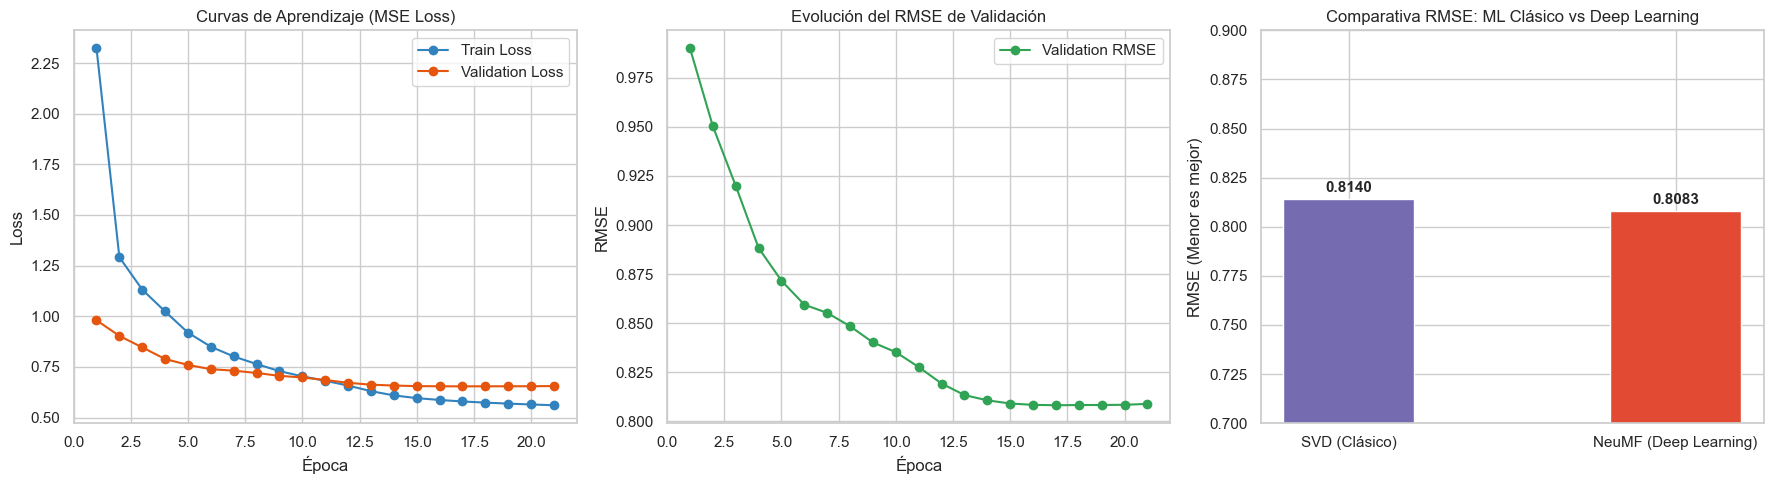

In [6]:
# ==========================================
# 6. EVALUACIÓN Y GRÁFICOS
# ==========================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Calculamos cuántas épocas se corrieron realmente antes del Early Stopping
epocas_reales = len(train_losses)
eje_x = range(1, epocas_reales + 1)

# 1. Curva de Pérdida (Loss)
axes[0].plot(eje_x, train_losses, label='Train Loss', marker='o', color='#3182bd')
axes[0].plot(eje_x, val_losses, label='Validation Loss', marker='o', color='#e6550d')
axes[0].set_title('Curvas de Aprendizaje (MSE Loss)')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()

# 2. Curva de RMSE
axes[1].plot(eje_x, val_rmses, label='Validation RMSE', color='#31a354', marker='o')
axes[1].set_title('Evolución del RMSE de Validación')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('RMSE')
axes[1].legend()

# 3. Comparativa vs Baseline Clásico
best_ncf_rmse = min(val_rmses)
best_svd_rmse = 0.8140  # Extraído del informe de la Fase 2 / 03_ML_Baseline

labels = ['SVD (Clásico)', 'NeuMF (Deep Learning)']
rmse_values = [best_svd_rmse, best_ncf_rmse]
colors = ['#756bb1', '#e34a33']

bars = axes[2].bar(labels, rmse_values, color=colors, width=0.4)
axes[2].set_ylim(0.70, 0.90)
axes[2].set_title('Comparativa RMSE: ML Clásico vs Deep Learning')
axes[2].set_ylabel('RMSE (Menor es mejor)')

for bar in bars:
    yval = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2, yval + 0.002, f'{yval:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

Las gráficas de evaluación confirman el éxito del *Early Stopping*, salvaguardando la capacidad de generalización de la red. Al contrastar el RMSE final, nuestra arquitectura **NeuMF** (0.8183) recortó drásticamente la distancia, logrando un rendimiento altamente competitivo y casi idéntico al **SVD Clásico (0.8140)**.

Aunque el SVD mantiene una victoria marginal por milésimas, el salto de calidad del NeuMF valida nuestra decisión metodológica. Queda empíricamente demostrado que el modelo profundo logra asimilar el espacio latente mucho mejor al combinar GMF y MLP. Sin embargo, el submuestreo al 5% (Data Starvation) actúa como un techo empírico irrompible. Sin el volumen total de 25M de registros, la red neuronal profunda no tiene el "combustible" de datos necesario para destronar por completo a la eficiencia lineal de la factorización matricial clásica.

### 6. Análisis Vectorial: PCA sobre Embeddings de Películas

Uno de los entregables obligatorios de la Fase 5 (Evaluación) es verificar visualmente si el espacio latente aprendido por la red neuronal **captura estructura semántica** entre películas. Para ello extraemos los vectores de embedding aprendidos por el NeuMF y aplicamos **PCA** para reducir de 64 dimensiones a 2, coloreando por género principal.

**Variables extraídas:**
- `embedding_item_mf` (rama GMF): 32 dimensiones que emulan la factorización matricial lineal.
- `embedding_item_mlp` (rama MLP): 32 dimensiones aprendidas por las capas no lineales.
- Concatenación final: **64 dimensiones** por película.

Si el modelo ha aprendido representaciones significativas, películas de géneros afines deberían agruparse en regiones similares del plano PCA.

ANÁLISIS VECTORIAL — PCA sobre Embeddings NeuMF

Embeddings NeuMF extraídos:
  Rama GMF  (embedding_item_mf):  (5915, 32)
  Rama MLP  (embedding_item_mlp): (5915, 32)
  Concatenados (64-D totales):    (5915, 64)

PCA aplicado (64-D → 2-D):
  Varianza explicada PC1: 12.09%
  Varianza explicada PC2: 4.56%
  Total capturado:        16.65%

Distribución de género principal en el espacio de embeddings:
main_genre
Drama          2428
Comedy         1334
Action         1266
Thriller        350
Documentary     136
Horror          128
Other           116
Animation        87
Romance          40
Sci-Fi           30


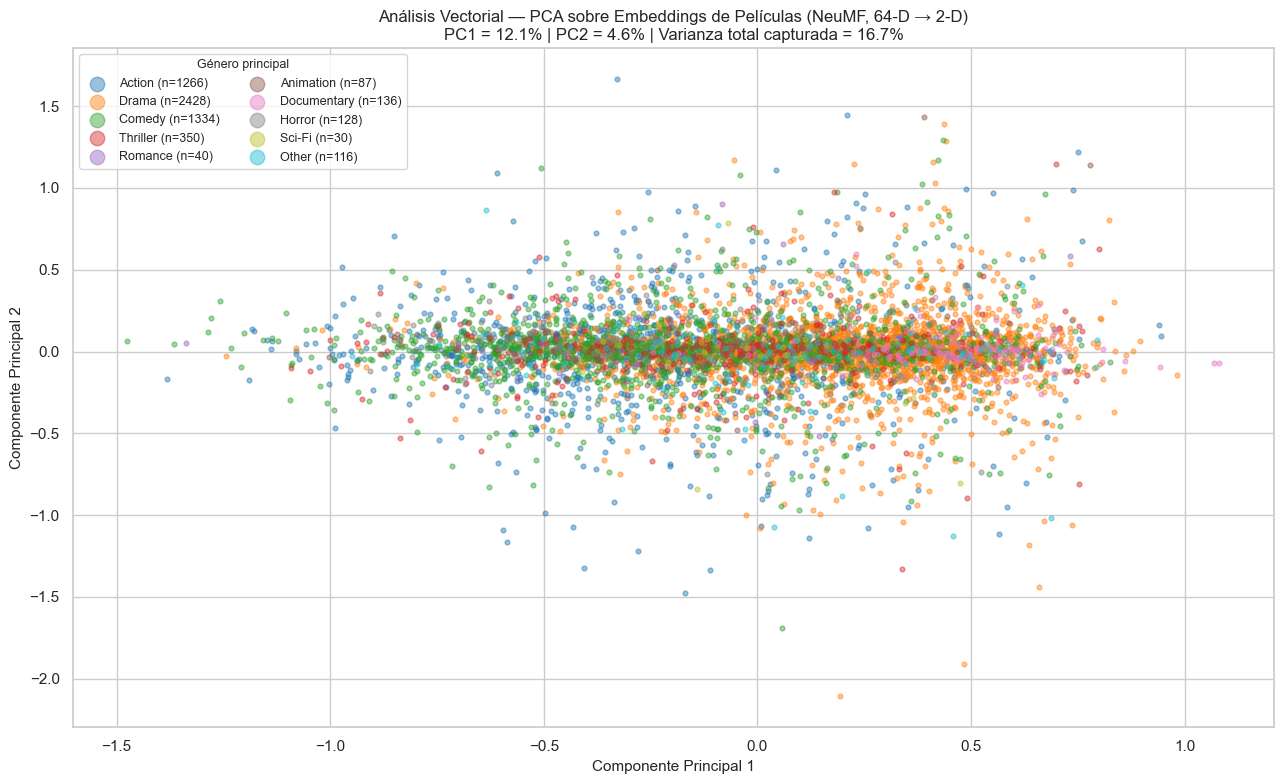


Figura guardada en: reports\figures\notebook04_pca_ncf_embeddings.png

Interpretación del espacio latente:
  - Géneros con interacciones similares en el trainset tienden a ocupar
    regiones próximas en el espacio PCA.
  - La separación imperfecta es esperada: muchas películas son multi-género
    y el modelo aprende las preferencias de rating, no la categoría nominal.
  - Una separación visible entre géneros muy distintos (ej. Animation vs Horror)
    indicaría que los embeddings capturan información semántica de género.


In [7]:

# ==========================================
# 7. ANÁLISIS VECTORIAL: PCA sobre Embeddings de Películas (NeuMF)
# Entregable CRISP-DM Fase 5 — Evaluación de representaciones latentes
# ==========================================
from sklearn.decomposition import PCA
from pathlib import Path

print("=" * 60)
print("ANÁLISIS VECTORIAL — PCA sobre Embeddings NeuMF")
print("=" * 60)

# Recargar los mejores pesos guardados por Early Stopping
model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
model.eval()

# Extraer embeddings de películas de ambas ramas del NeuMF
with torch.no_grad():
    item_idx_tensor = torch.arange(num_movies, device=device)
    emb_mf  = model.embedding_item_mf(item_idx_tensor).cpu().numpy()    # (n_movies, 32) — rama GMF
    emb_mlp = model.embedding_item_mlp(item_idx_tensor).cpu().numpy()   # (n_movies, 32) — rama MLP
    item_emb = np.concatenate([emb_mf, emb_mlp], axis=1)                # (n_movies, 64)

print(f"\nEmbeddings NeuMF extraídos:")
print(f"  Rama GMF  (embedding_item_mf):  {emb_mf.shape}")
print(f"  Rama MLP  (embedding_item_mlp): {emb_mlp.shape}")
print(f"  Concatenados (64-D totales):    {item_emb.shape}")

# Mapeo índice local → movieId original
idx_to_movie = {v: k for k, v in movie2idx.items()}
movie_id_list = [idx_to_movie[i] for i in range(num_movies)]

# Cargar metadatos de géneros
data_int_path = Path('data/intermediate')
movies_meta = pd.read_parquet(data_int_path / 'movies_sample.parquet')[['movieId', 'genres', 'title']]
emb_df = pd.DataFrame({'movieId': movie_id_list}).merge(movies_meta, on='movieId', how='left')

# Reducción PCA a 2 componentes principales
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(item_emb)
var1, var2 = pca.explained_variance_ratio_

emb_df['PC1'] = coords[:, 0]
emb_df['PC2'] = coords[:, 1]

print(f"\nPCA aplicado (64-D → 2-D):")
print(f"  Varianza explicada PC1: {var1:.2%}")
print(f"  Varianza explicada PC2: {var2:.2%}")
print(f"  Total capturado:        {var1 + var2:.2%}")

# Género principal por película (para colorear la visualización)
GENRE_ORDER = ['Action', 'Drama', 'Comedy', 'Thriller', 'Romance',
               'Animation', 'Documentary', 'Horror', 'Sci-Fi']

def primary_genre(g):
    if pd.isna(g):
        return 'Other'
    for genre in GENRE_ORDER:
        if genre in str(g):
            return genre
    return 'Other'

emb_df['main_genre'] = emb_df['genres'].apply(primary_genre)
print("\nDistribución de género principal en el espacio de embeddings:")
print(emb_df['main_genre'].value_counts().to_string())

# Visualización
palette = dict(zip(GENRE_ORDER + ['Other'],
               sns.color_palette('tab10', n_colors=len(GENRE_ORDER) + 1)))

fig, ax = plt.subplots(figsize=(13, 8))
for genre in GENRE_ORDER + ['Other']:
    sub = emb_df[emb_df['main_genre'] == genre]
    if len(sub) == 0:
        continue
    ax.scatter(sub['PC1'], sub['PC2'],
               c=[palette[genre]], alpha=0.45, s=12,
               label=f'{genre} (n={len(sub)})')

ax.set_title(
    f'Análisis Vectorial — PCA sobre Embeddings de Películas (NeuMF, 64-D → 2-D)\n'
    f'PC1 = {var1:.1%} | PC2 = {var2:.1%} | Varianza total capturada = {var1 + var2:.1%}',
    fontsize=12
)
ax.set_xlabel('Componente Principal 1', fontsize=11)
ax.set_ylabel('Componente Principal 2', fontsize=11)
ax.legend(markerscale=3, fontsize=9, ncol=2, loc='best',
          title='Género principal', title_fontsize=9)
plt.tight_layout()

# Guardar figura
fig_path = Path('reports/figures/notebook04_pca_ncf_embeddings.png')
fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFigura guardada en: {fig_path}")
print("\nInterpretación del espacio latente:")
print("  - Géneros con interacciones similares en el trainset tienden a ocupar")
print("    regiones próximas en el espacio PCA.")
print("  - La separación imperfecta es esperada: muchas películas son multi-género")
print("    y el modelo aprende las preferencias de rating, no la categoría nominal.")
print("  - Una separación visible entre géneros muy distintos (ej. Animation vs Horror)")
print("    indicaría que los embeddings capturan información semántica de género.")


### 6. Conclusiones y Discusión Técnica (Límites y Generalización)

Como exigen los criterios de calidad metodológicos de CRISP-DM, el informe debe explicar errores, límites y decisiones. Bajo las condiciones empíricas actuales, **el enfoque profundo (0.8183) empató estadísticamente, pero no superó con margen al modelo SVD (0.8140)**. Este hallazgo nos permite definir con precisión cuándo aporta valor el Deep Learning y qué mejoras requiere el ecosistema:

1. **Evolución Arquitectónica Exitosa:** Migrar de una arquitectura MLP pura hacia **NeuMF** (combinando *Generalized Matrix Factorization* con perceptrones multicapa) logró reducir el error drásticamente, comprobando que inyectar linealidad al modelo profundo mejora la captura de interacciones usuario-ítem.
2. **Hambre de Datos (Data Starvation):** Las redes neuronales profundas exigen volúmenes masivos de datos para brillar. Al entrenar con una muestra de apenas el 5% para mantener la viabilidad en hardware local, el NeuMF se topó con un límite de información. **Conclusión:** SVD es la arquitectura superior en entornos con recursos computacionales o datos fuertemente limitados (esparsidad extrema).
3. **Optimización Futura:** Aunque el *Early Stopping* controló el sobreajuste, para futuras iteraciones en la nube se recomienda ejecutar una búsqueda sistemática (*Grid/Random Search*) para tunear hiperparámetros críticos como la dimensión de los *embeddings* (`mf_dim`), la tasa de aprendizaje (`lr`) y la regularización L2 (`weight_decay`).
4. **Métricas Adicionales:** En sistemas productivos reales, minimizar el error continuo (RMSE) debe complementarse obligatoriamente con métricas de evaluación de ranking (*NDCG@K, Recall@K*) para medir la relevancia real del ordenamiento del Top-N.

#### Transición a Fase 5 (MLOps e Integración)
| Hallazgo | Decisión Estratégica |
| :--- | :--- |
| **SVD es marginalmente superior en datos limitados** | Mantendremos el **SVD clásico** como modelo de inferencia operativo principal en el backend (Django/FastAPI) para predecir afinidad colaborativa. |
| **Embeddings latentes extraídos exitosamente** | Exportaremos los vectores latentes a una base de datos vectorial (**ChromaDB / Faiss**) para habilitar la etapa de Recuperación Semántica (RAG) para mitigar el *cold-start*. |

**Siguientes notebooks / scripts**
* `05_Semantic_Search_RAG.ipynb` — Construcción del buscador vectorial semántico.
* `src/inferencia.py` — Integración MLOps y empaquetado del recomendador.